In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil

# Source directories
train_dir = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train"
test_dir = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"

# Target directory
merged_dir = "/kaggle/working/merged_dataset"
os.makedirs(merged_dir, exist_ok=True)

# Function to copy images maintaining class subfolders
def copy_images(src_dir, dst_dir):
    for class_name in os.listdir(src_dir):
        class_src_path = os.path.join(src_dir, class_name)
        class_dst_path = os.path.join(dst_dir, class_name)
        os.makedirs(class_dst_path, exist_ok=True)
        for img_name in os.listdir(class_src_path):
            src_img_path = os.path.join(class_src_path, img_name)
            dst_img_path = os.path.join(class_dst_path, img_name)
            if not os.path.exists(dst_img_path):  # avoid overwriting
                shutil.copy(src_img_path, dst_img_path)

# Copy train and test images to merged folder
copy_images(train_dir, merged_dir)
copy_images(test_dir, merged_dir)

print(f"Merged dataset created at: {merged_dir}")


Merged dataset created at: /kaggle/working/merged_dataset


In [2]:
import os
import shutil
from torchvision import datasets
from sklearn.model_selection import train_test_split

# Define the path to the original dataset and the new directory to save the splits
dataset_dir = '/kaggle/working/merged_dataset'
output_dir = '/kaggle/working/split_dataset'

# Create output directories for train, validation, and test splits
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')
test_dir = os.path.join(output_dir, 'test')

# Make sure the directories exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root=dataset_dir)

# Create a split for 80% training, 10% validation, and 10% test using sklearn's train_test_split
# Split images and labels
image_paths = [img_path for img_path, _ in dataset.imgs]
labels = [label for _, label in dataset.imgs]

# First split (train + val/test)
train_paths, val_test_paths, train_labels, val_test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42)

# Second split (val + test)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    val_test_paths, val_test_labels, test_size=0.5, stratify=val_test_labels, random_state=42)

# Function to move images to the corresponding folder
def move_images(image_paths, labels, folder):
    for path, label in zip(image_paths, labels):
        class_name = dataset.classes[label]
        class_dir = os.path.join(folder, class_name)
        os.makedirs(class_dir, exist_ok=True)
        shutil.copy(path, os.path.join(class_dir, os.path.basename(path)))

# Move the files to their respective directories
move_images(train_paths, train_labels, train_dir)
move_images(val_paths, val_labels, val_dir)
move_images(test_paths, test_labels, test_dir)

# Verify that the directories are created and files are moved
print(f"Training set saved to: {train_dir}")
print(f"Validation set saved to: {val_dir}")
print(f"Testing set saved to: {test_dir}")


Training set saved to: /kaggle/working/split_dataset/train
Validation set saved to: /kaggle/working/split_dataset/val
Testing set saved to: /kaggle/working/split_dataset/test



==== Training VGG16 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 224MB/s] 


Epoch 1/15 | Train Loss: 0.6990 | Train Acc: 0.6761 | Val Loss: 0.4730 | Val Acc: 0.7821 | Test Loss: 0.4868 | Test Acc: 0.7743
Epoch 2/15 | Train Loss: 0.4563 | Train Acc: 0.7919 | Val Loss: 0.4150 | Val Acc: 0.8403 | Test Loss: 0.4012 | Test Acc: 0.8490
Epoch 3/15 | Train Loss: 0.3551 | Train Acc: 0.8464 | Val Loss: 0.3391 | Val Acc: 0.8481 | Test Loss: 0.3461 | Test Acc: 0.8481
Epoch 4/15 | Train Loss: 0.2658 | Train Acc: 0.8901 | Val Loss: 0.2480 | Val Acc: 0.8941 | Test Loss: 0.2520 | Test Acc: 0.8915
Epoch 5/15 | Train Loss: 0.2119 | Train Acc: 0.9145 | Val Loss: 0.2099 | Val Acc: 0.9132 | Test Loss: 0.2486 | Test Acc: 0.8880
Epoch 6/15 | Train Loss: 0.1577 | Train Acc: 0.9374 | Val Loss: 0.1939 | Val Acc: 0.9201 | Test Loss: 0.2036 | Test Acc: 0.9149
Epoch 7/15 | Train Loss: 0.1259 | Train Acc: 0.9512 | Val Loss: 0.1249 | Val Acc: 0.9549 | Test Loss: 0.1290 | Test Acc: 0.9505
Epoch 8/15 | Train Loss: 0.0826 | Train Acc: 0.9687 | Val Loss: 0.1454 | Val Acc: 0.9436 | Test Loss: 0.

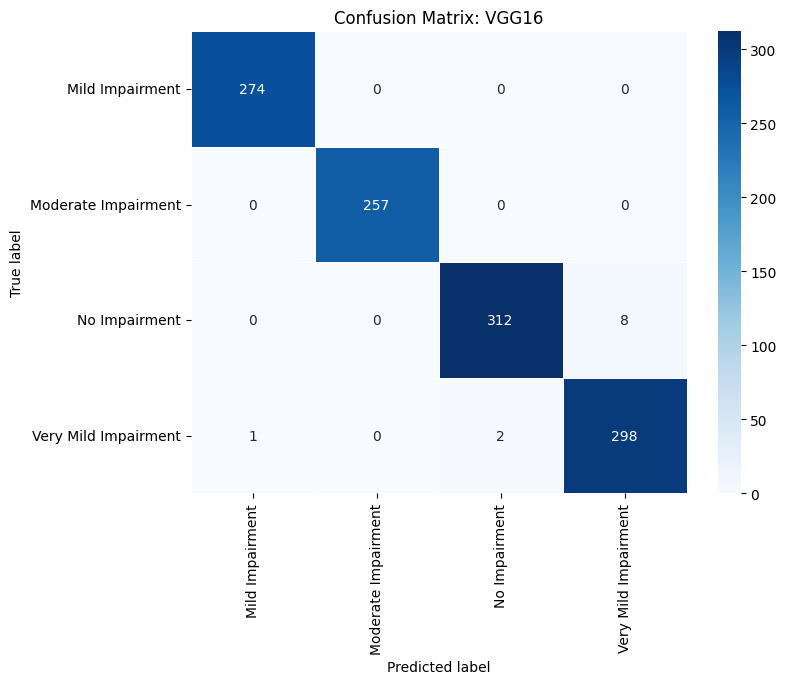

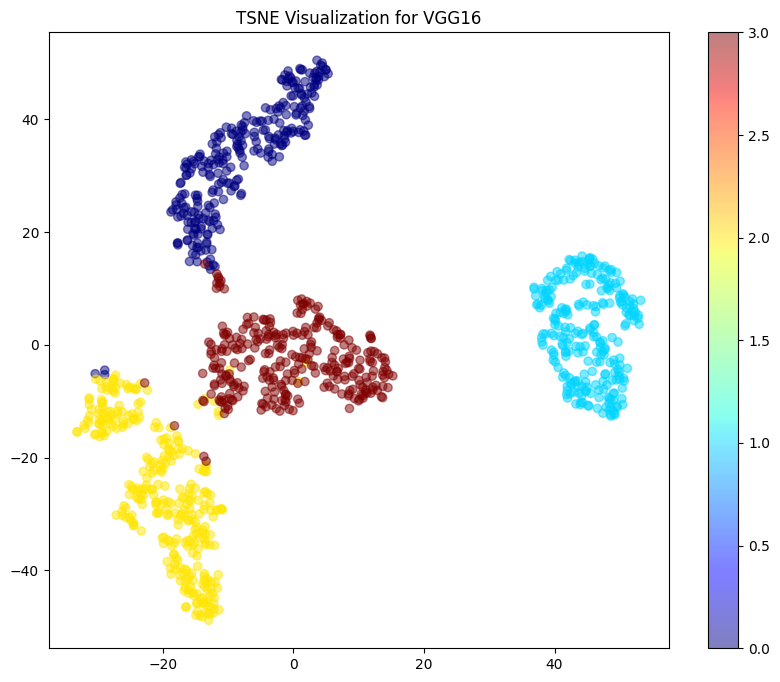

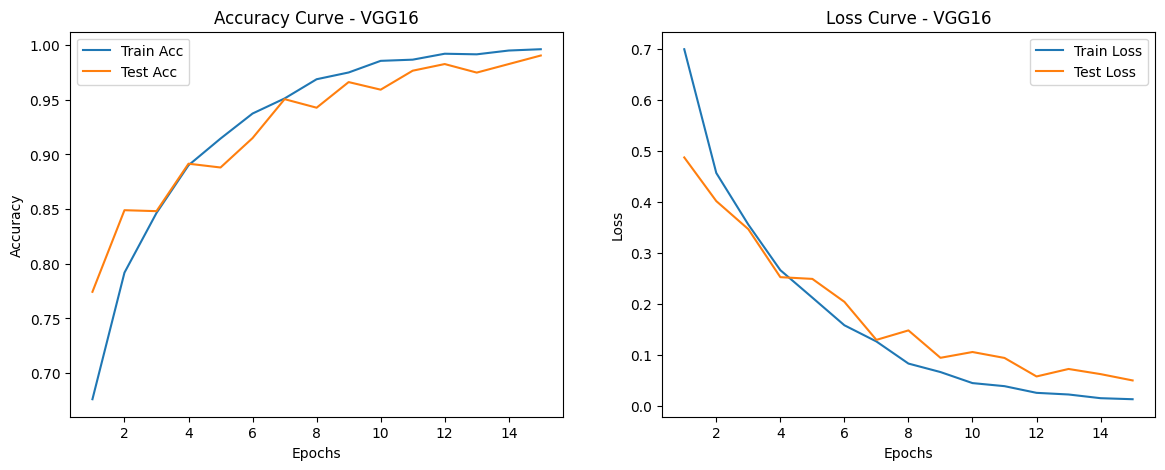

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



==== Training ResNet18 ====


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


Epoch 1/15 | Train Loss: 0.6329 | Train Acc: 0.7270 | Val Loss: 0.4401 | Val Acc: 0.8125 | Test Loss: 0.4136 | Test Acc: 0.8290
Epoch 2/15 | Train Loss: 0.3942 | Train Acc: 0.8326 | Val Loss: 0.3517 | Val Acc: 0.8533 | Test Loss: 0.3320 | Test Acc: 0.8663
Epoch 3/15 | Train Loss: 0.3097 | Train Acc: 0.8733 | Val Loss: 0.2716 | Val Acc: 0.8932 | Test Loss: 0.2525 | Test Acc: 0.9054
Epoch 4/15 | Train Loss: 0.2453 | Train Acc: 0.9019 | Val Loss: 0.2699 | Val Acc: 0.8976 | Test Loss: 0.2425 | Test Acc: 0.9054
Epoch 5/15 | Train Loss: 0.1837 | Train Acc: 0.9294 | Val Loss: 0.2006 | Val Acc: 0.9236 | Test Loss: 0.1882 | Test Acc: 0.9323
Epoch 6/15 | Train Loss: 0.1508 | Train Acc: 0.9450 | Val Loss: 0.1568 | Val Acc: 0.9418 | Test Loss: 0.1348 | Test Acc: 0.9523
Epoch 7/15 | Train Loss: 0.1237 | Train Acc: 0.9545 | Val Loss: 0.1454 | Val Acc: 0.9436 | Test Loss: 0.1079 | Test Acc: 0.9653
Epoch 8/15 | Train Loss: 0.1040 | Train Acc: 0.9626 | Val Loss: 0.1306 | Val Acc: 0.9514 | Test Loss: 0.

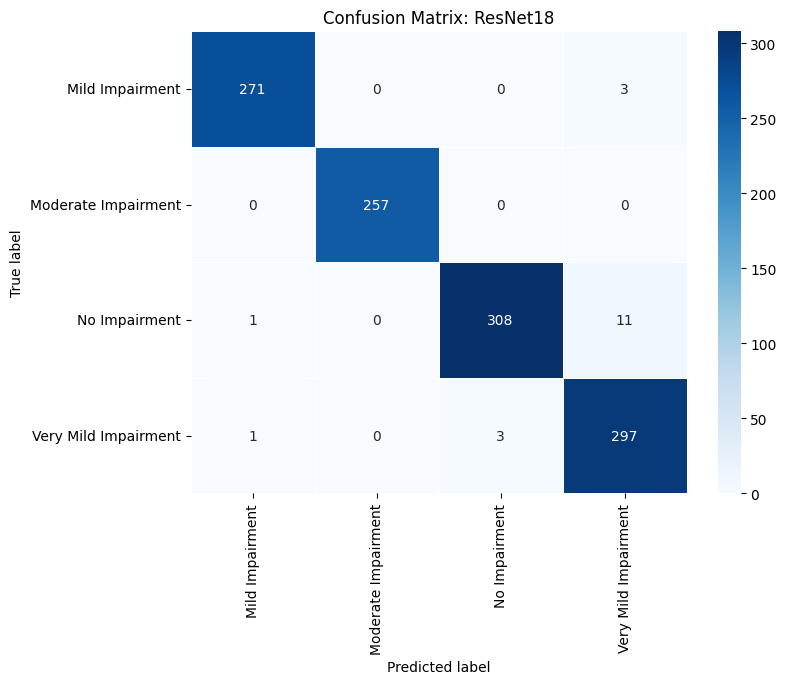

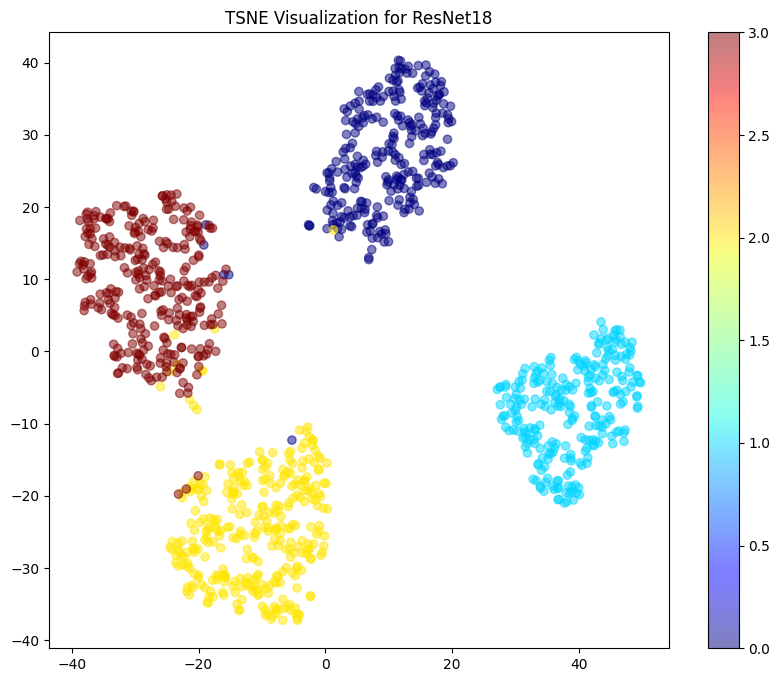

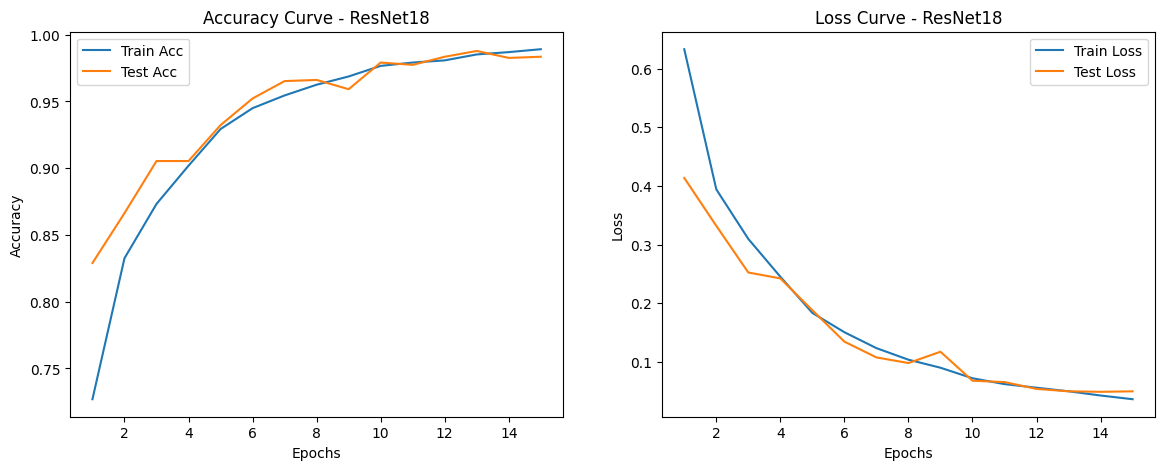


==== Training ResNet50 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


Epoch 1/15 | Train Loss: 0.5923 | Train Acc: 0.7397 | Val Loss: 0.4088 | Val Acc: 0.8108 | Test Loss: 0.3950 | Test Acc: 0.8220
Epoch 2/15 | Train Loss: 0.3612 | Train Acc: 0.8474 | Val Loss: 0.2861 | Val Acc: 0.8828 | Test Loss: 0.2828 | Test Acc: 0.8802
Epoch 3/15 | Train Loss: 0.2527 | Train Acc: 0.9003 | Val Loss: 0.2848 | Val Acc: 0.8845 | Test Loss: 0.2307 | Test Acc: 0.9115
Epoch 4/15 | Train Loss: 0.1810 | Train Acc: 0.9326 | Val Loss: 0.1848 | Val Acc: 0.9262 | Test Loss: 0.1511 | Test Acc: 0.9401
Epoch 5/15 | Train Loss: 0.1357 | Train Acc: 0.9502 | Val Loss: 0.1725 | Val Acc: 0.9384 | Test Loss: 0.1391 | Test Acc: 0.9427
Epoch 6/15 | Train Loss: 0.0971 | Train Acc: 0.9647 | Val Loss: 0.1497 | Val Acc: 0.9444 | Test Loss: 0.1217 | Test Acc: 0.9601
Epoch 7/15 | Train Loss: 0.0761 | Train Acc: 0.9745 | Val Loss: 0.0823 | Val Acc: 0.9714 | Test Loss: 0.0808 | Test Acc: 0.9722
Epoch 8/15 | Train Loss: 0.0563 | Train Acc: 0.9824 | Val Loss: 0.0473 | Val Acc: 0.9852 | Test Loss: 0.

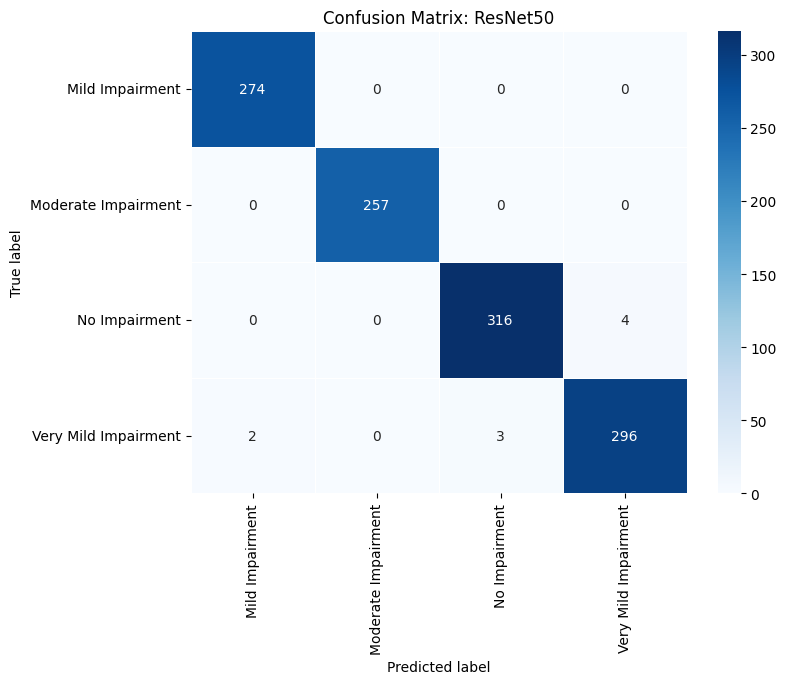

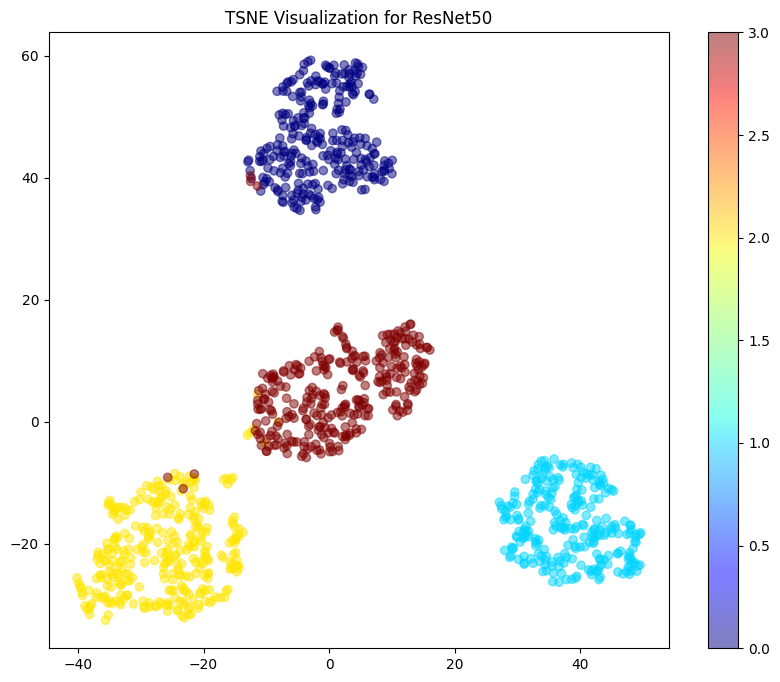

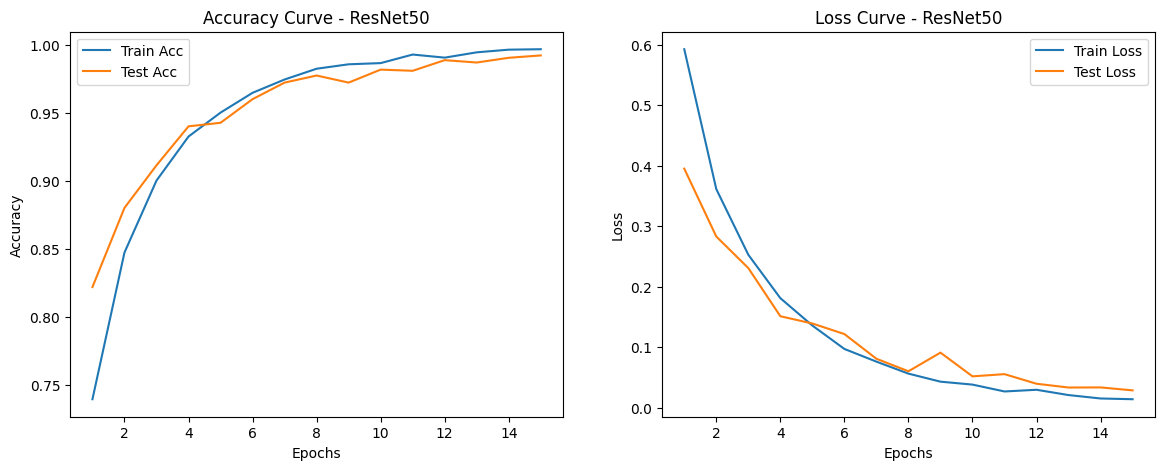


==== Training EfficientNetB3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 192MB/s]


Epoch 1/15 | Train Loss: 1.0364 | Train Acc: 0.5621 | Val Loss: 0.6534 | Val Acc: 0.6988 | Test Loss: 0.6492 | Test Acc: 0.7109
Epoch 2/15 | Train Loss: 0.6216 | Train Acc: 0.7259 | Val Loss: 0.5132 | Val Acc: 0.7795 | Test Loss: 0.4934 | Test Acc: 0.7847
Epoch 3/15 | Train Loss: 0.5173 | Train Acc: 0.7728 | Val Loss: 0.4355 | Val Acc: 0.8125 | Test Loss: 0.4146 | Test Acc: 0.8247
Epoch 4/15 | Train Loss: 0.4622 | Train Acc: 0.7966 | Val Loss: 0.3949 | Val Acc: 0.8255 | Test Loss: 0.3765 | Test Acc: 0.8481
Epoch 5/15 | Train Loss: 0.4030 | Train Acc: 0.8300 | Val Loss: 0.3650 | Val Acc: 0.8351 | Test Loss: 0.3357 | Test Acc: 0.8585
Epoch 6/15 | Train Loss: 0.3618 | Train Acc: 0.8461 | Val Loss: 0.3125 | Val Acc: 0.8646 | Test Loss: 0.3011 | Test Acc: 0.8750
Epoch 7/15 | Train Loss: 0.3295 | Train Acc: 0.8609 | Val Loss: 0.2969 | Val Acc: 0.8707 | Test Loss: 0.2750 | Test Acc: 0.8845
Epoch 8/15 | Train Loss: 0.3007 | Train Acc: 0.8772 | Val Loss: 0.2611 | Val Acc: 0.8889 | Test Loss: 0.

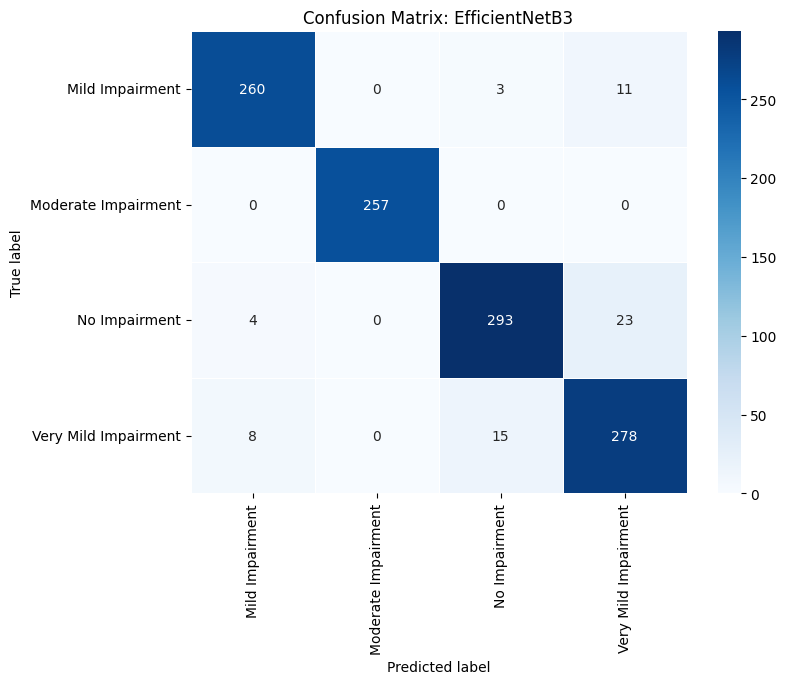

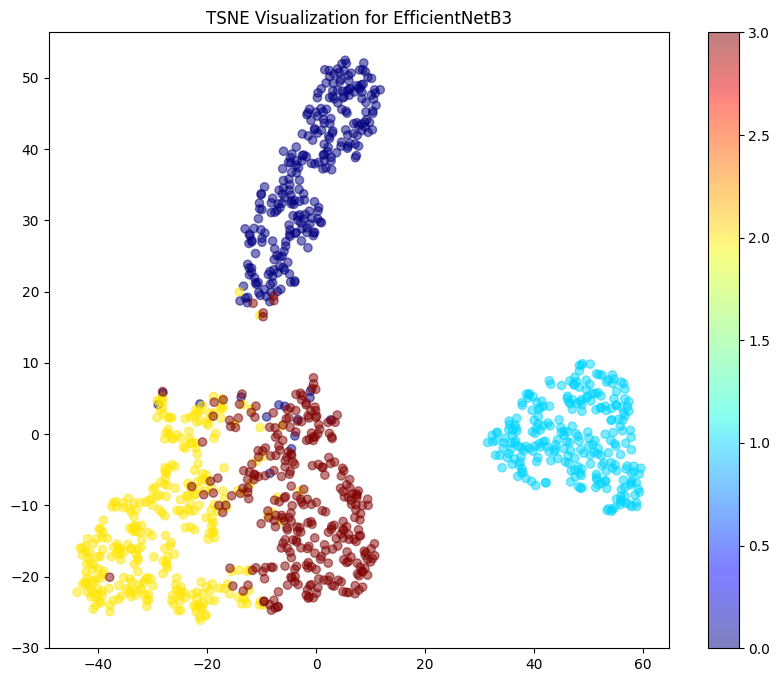

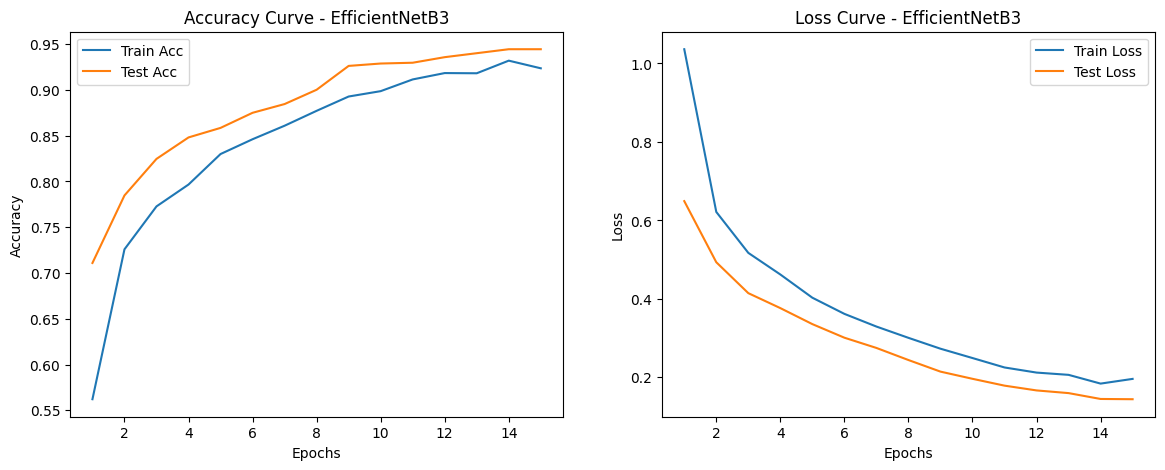

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth



==== Training DenseNet ====


100%|██████████| 30.8M/30.8M [00:00<00:00, 230MB/s]


Epoch 1/15 | Train Loss: 0.6812 | Train Acc: 0.7130 | Val Loss: 0.4375 | Val Acc: 0.8064 | Test Loss: 0.4443 | Test Acc: 0.8073
Epoch 2/15 | Train Loss: 0.4057 | Train Acc: 0.8315 | Val Loss: 0.3398 | Val Acc: 0.8576 | Test Loss: 0.3476 | Test Acc: 0.8524
Epoch 3/15 | Train Loss: 0.2952 | Train Acc: 0.8890 | Val Loss: 0.2702 | Val Acc: 0.8889 | Test Loss: 0.3014 | Test Acc: 0.8811
Epoch 4/15 | Train Loss: 0.2173 | Train Acc: 0.9187 | Val Loss: 0.2090 | Val Acc: 0.9210 | Test Loss: 0.2206 | Test Acc: 0.9158
Epoch 5/15 | Train Loss: 0.1580 | Train Acc: 0.9449 | Val Loss: 0.1608 | Val Acc: 0.9392 | Test Loss: 0.1715 | Test Acc: 0.9323
Epoch 6/15 | Train Loss: 0.1171 | Train Acc: 0.9606 | Val Loss: 0.1404 | Val Acc: 0.9453 | Test Loss: 0.1359 | Test Acc: 0.9479
Epoch 7/15 | Train Loss: 0.0933 | Train Acc: 0.9712 | Val Loss: 0.1148 | Val Acc: 0.9592 | Test Loss: 0.1349 | Test Acc: 0.9583
Epoch 8/15 | Train Loss: 0.0716 | Train Acc: 0.9773 | Val Loss: 0.0875 | Val Acc: 0.9688 | Test Loss: 0.

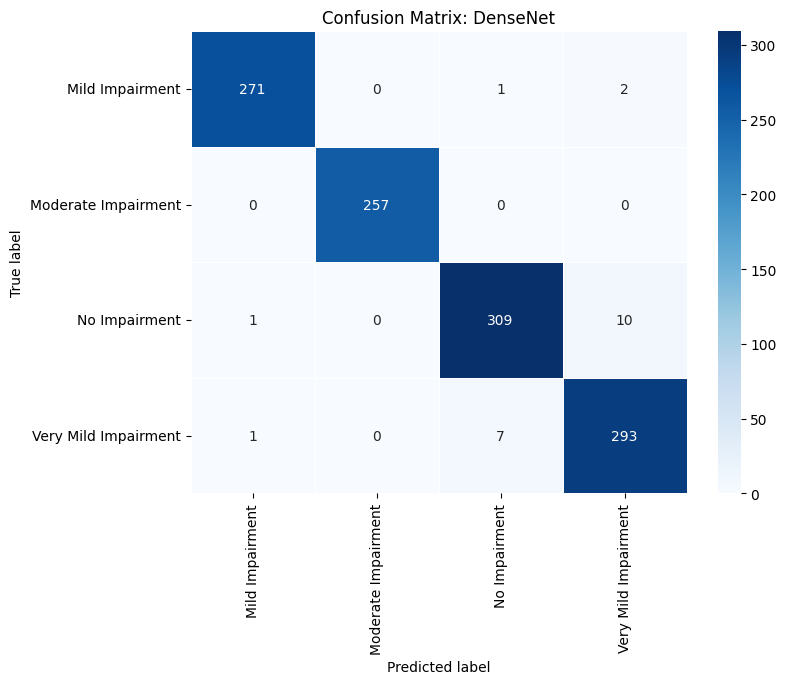

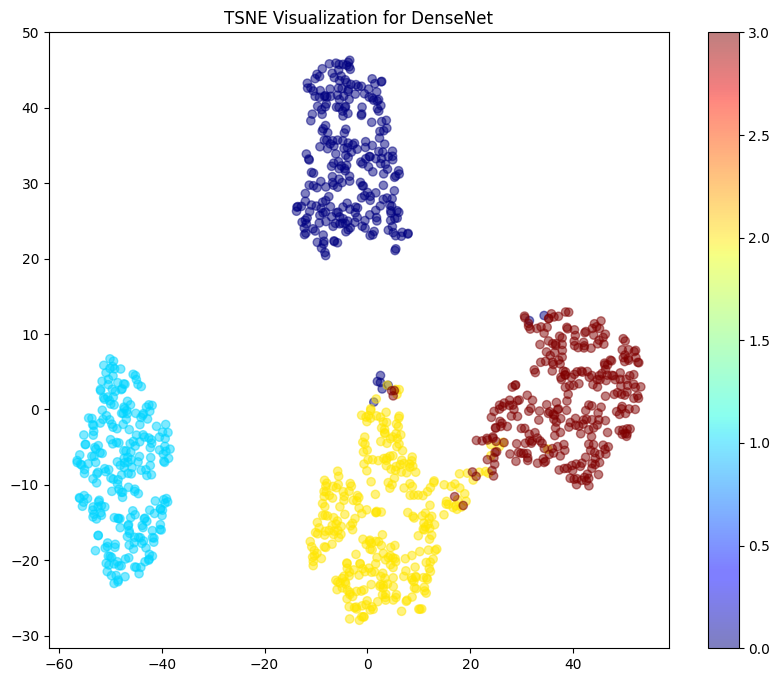

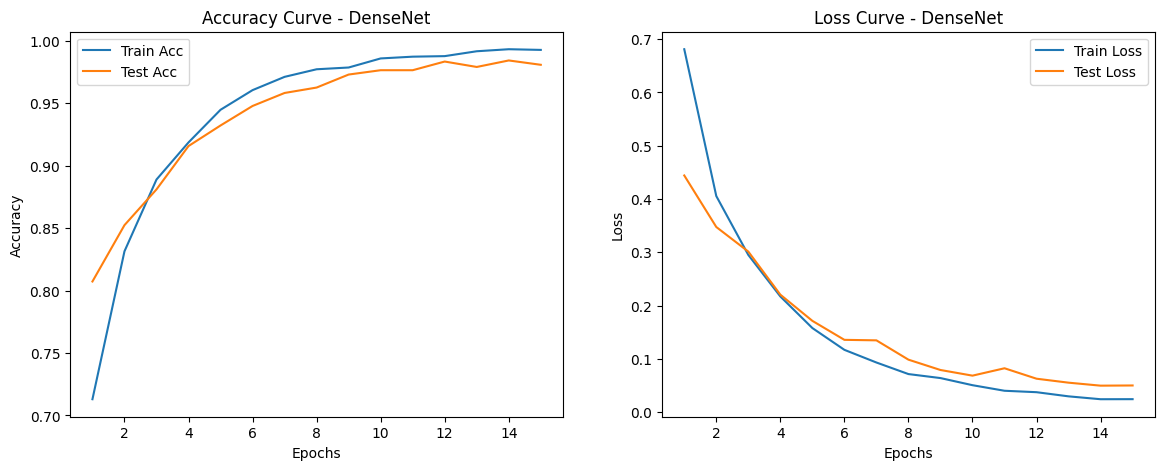


==== Training InceptionV3 ====


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 210MB/s] 


RuntimeError: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size

In [3]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Data Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model Definitions ----------------------
def create_model(model_name, num_classes):
     if model_name == 'InceptionV3':
        model = models.inception_v3(pretrained=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'VGG16':
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

     elif model_name == 'ResNet18':
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'ResNet50':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

     elif model_name == 'EfficientNetB3':
        model = models.efficientnet_b3(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

     elif model_name == 'DenseNet':
        model = models.densenet121(pretrained=True)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

  

     return model.to(device)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct, total, total_loss = 0, 0, 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, total_loss / total, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
def train_model(model_name, model, criterion, optimizer, scheduler, num_epochs=15):
    train_losses, val_losses, test_losses = [], [], []
    train_accs, val_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            running_corrects += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / total_train
        train_acc = running_corrects / total_train
        val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
        test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        scheduler.step()

    return model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels

# ---------------------- Confusion Matrix ----------------------
def plot_confusion_matrix(test_labels, test_preds, classes, model_name):
    cm = confusion_matrix(test_labels, test_preds)
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# ---------------------- TSNE Visualization ----------------------
def plot_tsne(model, test_loader, model_name):
    model.eval()
    features, labels = [], []

    with torch.no_grad():
        for images, lbls in test_loader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.cpu().numpy())

    features = np.concatenate(features)
    labels = np.concatenate(labels)

    tsne = TSNE(n_components=2, random_state=0)
    tsne_results = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='jet', alpha=0.5)
    plt.title(f"TSNE Visualization for {model_name}")
    plt.colorbar()
    plt.show()

# ---------------------- Plot Accuracy & Loss Curves ----------------------
def plot_curves(train_accs,test_accs, train_losses, test_losses, model_name):
    epochs = range(1, len(train_accs)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accs, label='Train Acc')
   
    plt.plot(epochs, test_accs, label='Test Acc')
    plt.title(f"Accuracy Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
   
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.title(f"Loss Curve - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# ---------------------- Training and Evaluating Each Model ----------------------
model_names = ['VGG16', 'ResNet18', 'ResNet50', 'EfficientNetB3', 'DenseNet', 'InceptionV3']
results = {}

for model_name in model_names:
    print(f"\n==== Training {model_name} ====")
    model = create_model(model_name, len(train_dataset.classes))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    model, train_losses, val_losses, test_losses, train_accs, val_accs, test_accs, test_preds, test_labels = train_model(
        model_name, model, criterion, optimizer, scheduler, num_epochs=15)

    precision = precision_score(test_labels, test_preds, average='weighted')
    recall = recall_score(test_labels, test_preds, average='weighted')
    f1 = f1_score(test_labels, test_preds, average='weighted')
    kappa = cohen_kappa_score(test_labels, test_preds)

    results[model_name] = {
        'train_acc': train_accs[-1], 'val_acc': val_accs[-1], 'test_acc': test_accs[-1],
        'precision': precision, 'recall': recall, 'f1': f1, 'kappa': kappa
    }

    print(f"\nResults for {model_name}:")
    print(f"Train Accuracy: {train_accs[-1]:.4f}, Val Accuracy: {val_accs[-1]:.4f}, Test Accuracy: {test_accs[-1]:.4f}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}, Cohen's Kappa: {kappa:.4f}")

    plot_confusion_matrix(test_labels, test_preds, test_dataset.classes, model_name)
    plot_tsne(model, test_loader, model_name)
    plot_curves(train_accs,test_accs, train_losses,test_losses, model_name)

# ---------------------- Display Results ----------------------
print("\nOverall Results:")
for model_name, metrics in results.items():
    print(f"{model_name}:")
    print(f" Train Acc: {metrics['train_acc']:.4f} | "
          f"Val Acc: {metrics['val_acc']:.4f} | "
          f"Test Acc: {metrics['test_acc']:.4f} | "
          f"Precision: {metrics['precision']:.4f} | "
          f"Recall: {metrics['recall']:.4f} | "
          f"F1 Score: {metrics['f1']:.4f} | "
          f"Kappa: {metrics['kappa']:.4f}")
    print("-" * 40)


Epoch 1/15 | Train Loss: 0.7258 | Train Acc: 0.6767 | Val Loss: 0.4640 | Val Acc: 0.7847 | Test Loss: 0.4441 | Test Acc: 0.8108
Epoch 2/15 | Train Loss: 0.4073 | Train Acc: 0.8245 | Val Loss: 0.3489 | Val Acc: 0.8429 | Test Loss: 0.3313 | Test Acc: 0.8602
Epoch 3/15 | Train Loss: 0.3003 | Train Acc: 0.8798 | Val Loss: 0.2656 | Val Acc: 0.8915 | Test Loss: 0.2635 | Test Acc: 0.8958
Epoch 4/15 | Train Loss: 0.2044 | Train Acc: 0.9209 | Val Loss: 0.1739 | Val Acc: 0.9323 | Test Loss: 0.1530 | Test Acc: 0.9453
Epoch 5/15 | Train Loss: 0.1500 | Train Acc: 0.9456 | Val Loss: 0.1245 | Val Acc: 0.9557 | Test Loss: 0.1132 | Test Acc: 0.9601
Epoch 6/15 | Train Loss: 0.1059 | Train Acc: 0.9643 | Val Loss: 0.1060 | Val Acc: 0.9601 | Test Loss: 0.0920 | Test Acc: 0.9679
Epoch 7/15 | Train Loss: 0.0802 | Train Acc: 0.9723 | Val Loss: 0.0885 | Val Acc: 0.9661 | Test Loss: 0.0845 | Test Acc: 0.9705
Epoch 8/15 | Train Loss: 0.0617 | Train Acc: 0.9793 | Val Loss: 0.0994 | Val Acc: 0.9635 | Test Loss: 0.

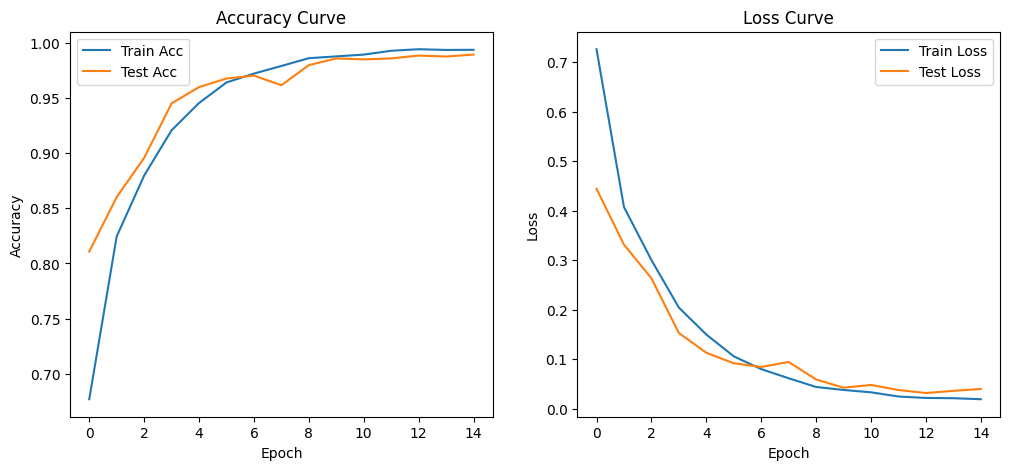

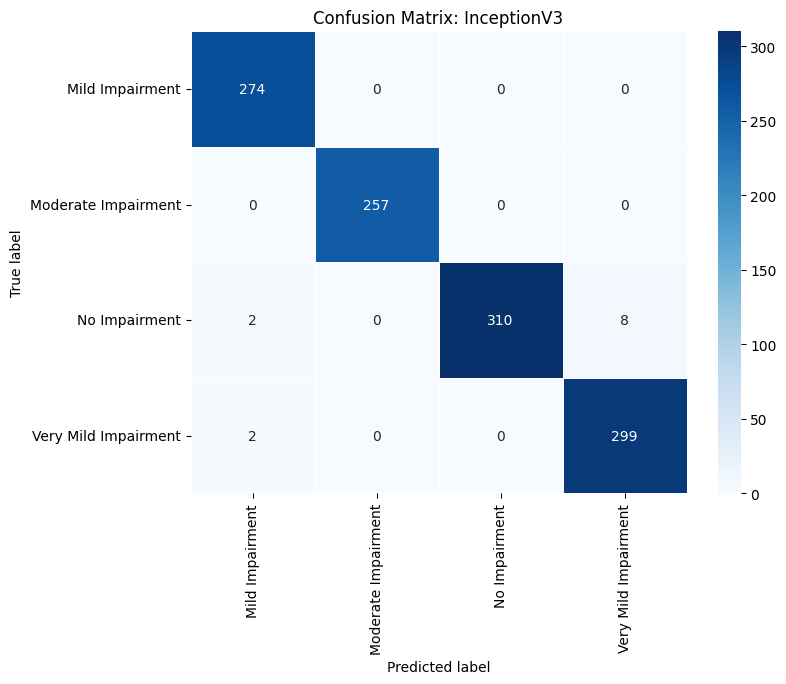

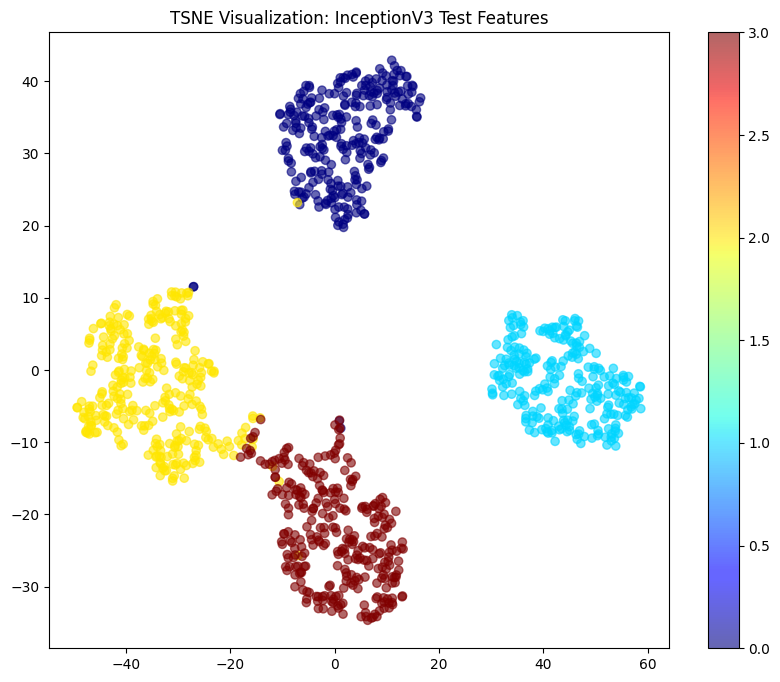


=== InceptionV3 Evaluation Metrics ===
Train Accuracy: 0.9986 | Precision: 0.9986 | Recall: 0.9986 | F1 Score: 0.9986 | Cohen's Kappa: 0.9981
Val Accuracy:   0.9922 | Precision: 0.9923 | Recall: 0.9922 | F1 Score: 0.9922 | Cohen's Kappa: 0.9896
Test Accuracy:  0.9896 | Precision: 0.9898 | Recall: 0.9896 | F1 Score: 0.9896 | Cohen's Kappa: 0.9861

Metrics saved to /kaggle/working/inceptionv3_metrics_summary.csv


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Model ----------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
num_classes = len(train_dataset.classes)
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ---------------------- Loss and Optimizer ----------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ---------------------- Evaluation Function ----------------------
def evaluate(loader, model, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, model, criterion)
    test_acc, test_loss, _, _ = evaluate(test_loader, model, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    scheduler.step()

# ---------------------- Accuracy & Loss Curves ----------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc')

plt.plot(test_accs, label='Test Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(False)  # Remove background boxes

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')

plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

# ---------------------- Confusion Matrix ----------------------
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)
cm = confusion_matrix(test_labels, test_preds)
df_cm = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
plt.figure(figsize=(8,6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix: InceptionV3")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# ---------------------- TSNE Visualization ----------------------
model.eval()
features, labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        features.append(outputs.cpu().numpy())
        labels.append(lbls.cpu().numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

tsne = TSNE(n_components=2, random_state=0)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10,8))
plt.scatter(tsne_results[:,0], tsne_results[:,1], c=labels, cmap='jet', alpha=0.6)
plt.title('TSNE Visualization: InceptionV3 Test Features')
plt.colorbar()
plt.show()

# ---------------------- Final Evaluation Metrics ----------------------
train_acc, train_loss, train_preds, train_labels = evaluate(train_loader, model, criterion)
val_acc, val_loss, val_preds, val_labels = evaluate(val_loader, model, criterion)
test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, model, criterion)

# Metrics calculation
train_precision = precision_score(train_labels, train_preds, average='weighted')
train_recall = recall_score(train_labels, train_preds, average='weighted')
train_f1 = f1_score(train_labels, train_preds, average='weighted')
train_kappa = cohen_kappa_score(train_labels, train_preds)

val_precision = precision_score(val_labels, val_preds, average='weighted')
val_recall = recall_score(val_labels, val_preds, average='weighted')
val_f1 = f1_score(val_labels, val_preds, average='weighted')
val_kappa = cohen_kappa_score(val_labels, val_preds)

test_precision = precision_score(test_labels, test_preds, average='weighted')
test_recall = recall_score(test_labels, test_preds, average='weighted')
test_f1 = f1_score(test_labels, test_preds, average='weighted')
test_kappa = cohen_kappa_score(test_labels, test_preds)

# Print metrics
print("\n=== InceptionV3 Evaluation Metrics ===")
print(f"Train Accuracy: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1 Score: {train_f1:.4f} | Cohen's Kappa: {train_kappa:.4f}")
print(f"Val Accuracy:   {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1 Score: {val_f1:.4f} | Cohen's Kappa: {val_kappa:.4f}")
print(f"Test Accuracy:  {test_acc:.4f} | Precision: {test_precision:.4f} | Recall: {test_recall:.4f} | F1 Score: {test_f1:.4f} | Cohen's Kappa: {test_kappa:.4f}")

# ---------------------- Save metrics to CSV ----------------------
results_df = pd.DataFrame({
    "Model": ["InceptionV3"],
    "Train Accuracy": [train_acc],
    "Train Precision": [train_precision],
    "Train Recall": [train_recall],
    "Train F1 Score": [train_f1],
    "Train Kappa": [train_kappa],
    "Val Accuracy": [val_acc],
    "Val Precision": [val_precision],
    "Val Recall": [val_recall],
    "Val F1 Score": [val_f1],
    "Val Kappa": [val_kappa],
    "Test Accuracy": [test_acc],
    "Test Precision": [test_precision],
    "Test Recall": [test_recall],
    "Test F1 Score": [test_f1],
    "Test Kappa": [test_kappa],
})

results_df.to_csv("/kaggle/working/inceptionv3_metrics_summary.csv", index=False)
print("\nMetrics saved to /kaggle/working/inceptionv3_metrics_summary.csv")
